# Financial Statements Analyzer

---

## Overview
This project builds a Python CLI that helps answer the question, "How healthy and sustainable is this business?" by pulling financial statements from Financial Modeling Prep to compute 12+ ratios across profitability, liquidity, solvency (leverage), and valuation to **score** the company's financial health.

---

## Data Fetching 
Pull income statement, balance sheet, and cash flow data

In [563]:
%matplotlib inline
import requests
import pandas as pd
import yfinance as yf

def get_financials(ticker: str) -> dict:
    """
    Fetches financial statements from yfinance using browser emulation headers.
    Defensively isolated to protect international data lookups.
    """
    print(f"Establishing secure session wrapper for {ticker}...")
    
    # 1. Build an authentic browser session footprint
    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Connection": "keep-alive"
    })
    
    # 2. Attach the session to yfinance
    stock = yf.Ticker(ticker, session=session)
    
    # 3. Pull structural tables independently
    inc_df = stock.financials
    bal_df = stock.balance_sheet
    cf_df  = stock.cashflow
    
    # Hard stop verification layer
    if inc_df is None or inc_df.empty or bal_df is None or bal_df.empty:
        print(f"\nSCRAPER ERROR: Yahoo Finance returned empty statements for {ticker}.")
        print("Yahoo may be temporarily rate-limiting your local IP address.")
        return {"income_stmt": pd.DataFrame(), "balance_sheet": pd.DataFrame(), "cash_flow": pd.DataFrame(), "info": {}}
        
    # 4. Defensive Metadata Lookup (Revised with clean zero fallbacks)
    info_dict = {}
    try:
        raw_info = stock.info
        if raw_info and isinstance(raw_info, dict):
            info_dict = {
                "currentPrice": float(raw_info.get("currentPrice", raw_info.get("previousClose", 0.0))),
                "trailingEps": float(raw_info.get("trailingEps", 0.0)),
                "marketCap": float(raw_info.get("marketCap", 0.0)),
                "bookValue": float(raw_info.get("bookValue", 0.0))
            }
    except Exception:
        # Fallback for international tickers where .info lookups break completely
        print(f"Metadata summary lookup restricted for {ticker}. Pulling live closing price...")
        
        # Pull live close price from history safely as a backup
        price_history = stock.history(period="1d")
        fallback_price = float(price_history["Close"].iloc[0]) if not price_history.empty else 0.0
        
        # FIX: Set missing metrics to 0.0 instead of hardcoding arbitrary estimates
        info_dict = {
            "currentPrice": fallback_price,
            "trailingEps": 0.0,  
            "marketCap": 0.0,
            "bookValue": 0.0
        }

    return {
        "income_stmt":  inc_df,
        "balance_sheet": bal_df,
        "cash_flow":    cf_df,
        "info":         info_dict
    }

---

## Financial Ratios Computation
Compute profitability ratios, liquidity and solvency ratios, and valuation ratios

### Profitability ratios
Financial metrics that assesses a company's **ability** to earn a profit relative to its **assets**, **equity**, and **sales** (Hayes, 2025)

* Gross margin
    * Difference between **sales revenue** and the **costs** of the products sold
    * High gross margin --> the company has a competitive advantage, allowing it to charge high for its products
    * Low gross margin --> the company has fierce competition
    * `Gross Profit / Total Revenue`
* Net margin
    * Measures the ability of a company to generate earnings after taking into account expenses and taxes
    * Signals the overall financial well-being of a company by determining whether it is generating enough profit from its sales
    * `Net Income / Total Revenue`
* Earning Before Interest, Taxes, Depreciation, and Amortization (EBITDA) Margin
    * Measures the company's operating profit as a percentage of its revenue (Chen, 2023)
    * `EBITDA / Total Revenue`
* Return on Assets (ROA)
    * How effective the company utilizes its assets to generate sales and profits?
    * `Net Income / Total Assets` 
* Return on Equity (ROE)
    * How effective are the company's equity investments in earning a return?
    * `Net Income / Equity`

### Liquidity and solvency ratios
Determines the company's ability to pay off short- and long-term debt without raising external capital (Hayes, 2025)
    
* Current Ratio
    * Ability of the company to pay off current liabilities with current assets
    * The higher the ratio, the better the company's liquidity
    * `Current Assets / Current Liabilities`
* Quick Ratio
    * Ability of the company to pay off short-term obligations with its liquid assets
    * `(Current Assets - Inventory) / Current Liabilities`
* Debt-to-Equity (D/E)
    * Measures the company's leverage in financing operations with debt rather than its own resources (Fernando, 2025)
    * `Total Debt / Equity`
* Total Debt-to-Assets
    * Measures the level of debt the company has compared to the assets it has (Hayes, 2025)
    * Higher ratio --> the company uses more debt to finance its assets
    * `Total Debt / Total Assets`

### Valuation ratios
Compares the company's market value and different financial metrics (Baltova, 2021)

* Price-to-Earning (P/E) Ratio
    * Signals if the company's stock is cheap or expensive by measuring its chare price with its earning per share
    * `Current Price / Earnings per Share`
* Price-to-Book (P/B) Ratio
    * Measures whether the company's equity justifies its share price
    * `Current Price / Book Value per Share`
* Enterprise Value (EV) per EBITDA
    * Measures the company's market value compared to its EBITDA
    * `Enterprise Value / EBITDA`
* Free Cash Flow (FCF) Yield
    * Measures the company's financial performance by comparing its FCF per share to its market price per share (Free Cash Flow Yield: Definition, Formula, and How to Calculate, n.d.)
    * `Free Cash Flow / Market Cap`

In [569]:
"""
Standardizes all index keys by forcing them to lowercase and removing spaces, then implements 
fallback search keys so it never fails to pull a line item again.
"""

import pandas as pd

def safe_lookup(df, keywords: list):
    """
    Defensively searches a DataFrame index using normalized string matches 
    to handle variable naming shifts on Yahoo Finance.
    """
    # Standardize the index: lowercase and strip spaces
    normalized_index = df.index.astype(str).str.lower().str.replace(" ", "").str.replace("_", "")
    
    for kw in keywords:
        clean_kw = kw.lower().replace(" ", "").replace("_", "")
        if clean_kw in normalized_index.values:
            # Find the actual original index label position
            idx_position = normalized_index.get_loc(clean_kw)
            # If the index location is a boolean mask, pick the first match
            if isinstance(idx_position, int):
                return df.iloc[idx_position]
            else:
                return df.iloc[idx_position].iloc[0]
                
    # Fallback to a row of zeros matching the column width if completely missing
    return pd.Series(0.0, index=df.columns)

def profitability(inc, bal):
    """Computes operational profitability margins defensively by normalizing date indexes."""
    # 1. Standardize column date formats to clean strings (YYYY-MM-DD)
    # This prevents pandas from failing to align mismatched datetime structures
    inc_clean = inc.copy()
    bal_clean = bal.copy()
    
    inc_clean.columns = pd.to_datetime(inc_clean.columns).strftime('%Y-%m-%d')
    bal_clean.columns = pd.to_datetime(bal_clean.columns).strftime('%Y-%m-%d')

    # 2. Perform safe lookups using our normalized copies
    rev    = safe_lookup(inc_clean, ["Total Revenue", "TotalRevenue", "Operating Revenue"])
    gp     = safe_lookup(inc_clean, ["Gross Profit", "GrossProfit"])
    ni     = safe_lookup(inc_clean, ["Net Income", "NetIncome", "Net Income Common Stockholders"])
    ebitda = safe_lookup(inc_clean, ["EBITDA"])
    
    equity = safe_lookup(bal_clean, ["Stockholders Equity", "StockholdersEquity", "Total Equity Gross Minority Interest"])
    assets = safe_lookup(bal_clean, ["Total Assets", "TotalAssets"])
    
    # 3. Compute baseline metrics
    gross_margin  = (gp / rev * 100).round(2).fillna(0)
    net_margin    = (ni / rev * 100).round(2).fillna(0)
    ebitda_margin = (ebitda / rev * 100).round(2).fillna(0)
    
    # 4. Safely calculate cross-statement ratios using explicit date mapping
    # If shapes still don't align, clip the data to the matching available years
    common_dates = inc_clean.columns.intersection(bal_clean.columns)
    
    if not common_dates.empty:
        roe = (ni[common_dates] / equity[common_dates] * 100).round(2).fillna(0)
        roa = (ni[common_dates] / assets[common_dates] * 100).round(2).fillna(0)
    else:
        # Emergency backup: If dates still conflict, align purely by sequence position
        min_len = min(len(ni), len(equity))
        roe = pd.Series((ni.iloc[:min_len].values / equity.iloc[:min_len].values * 100).round(2), index=ni.index[:min_len]).fillna(0)
        roa = pd.Series((ni.iloc[:min_len].values / assets.iloc[:min_len].values * 100).round(2), index=ni.index[:min_len]).fillna(0)
    
    return {
        "gross_margin":   gross_margin,
        "net_margin":     net_margin,
        "ebitda_margin":  ebitda_margin,
        "roe":            roe,   
        "roa":            roa,   
    }

def liquidity_solvency(bal):
    """Computes solvency capability metrics cleanly."""
    ca  = safe_lookup(bal, ["Current Assets", "CurrentAssets", "Total Current Assets"])
    cl  = safe_lookup(bal, ["Current Liabilities", "CurrentLiabilities", "Total Current Liabilities"])
    inv = safe_lookup(bal, ["Inventory", "Inventories"])
    td  = safe_lookup(bal, ["Total Debt", "TotalDebt"])
    eq  = safe_lookup(bal, ["Stockholders Equity", "StockholdersEquity"])
    ta  = safe_lookup(bal, ["Total Assets", "TotalAssets"])
    
    return {
        "current_ratio":  (ca / cl).round(2).fillna(0),           
        "quick_ratio":    ((ca - inv) / cl).round(2).fillna(0),   
        "debt_to_equity": (td / eq).round(2).fillna(0),           
        "debt_to_assets": (td / ta).round(2).fillna(0),           
    }

def valuation(info, inc, bal, cf):
    """Computes pricing metrics mapped against chronological time series indices."""
    price  = info.get("currentPrice", info.get("previousClose", 0))
    eps    = info.get("trailingEps", 0)
    bvps   = info.get("bookValue", 0)
    mktcap = info.get("marketCap", 0)
    
    # Extract structural scalar elements mapping to the LATEST chronological report year
    ebitda_series = safe_lookup(inc, ["EBITDA"])
    debt_series   = safe_lookup(bal, ["Total Debt", "TotalDebt"])
    cash_series   = safe_lookup(bal, ["Cash And Cash Equivalents", "CashAndCashEquivalents"])
    fcf_series    = safe_lookup(cf, ["Free Cash Flow", "FreeCashFlow"])
    
    # Grab the single first item (most recent report date element)
    ebitda = ebitda_series.iloc[0] if not ebitda_series.empty else 0
    debt   = debt_series.iloc[0] if not debt_series.empty else 0
    cash   = cash_series.iloc[0] if not cash_series.empty else 0
    fcf    = fcf_series.iloc[0] if not fcf_series.empty else 0
    
    ev     = mktcap + debt - cash  
    
    return {
        "pe_ratio":     round(price / eps, 2) if eps else 0,
        "pb_ratio":     round(price / bvps, 2) if bvps else 0,
        "ev_ebitda":    round(ev / ebitda, 2) if ebitda else 0,
        "fcf_yield":    round(fcf / mktcap * 100, 2) if mktcap else 0,
    }

---

## Scoring and Analysis
Rate each ratio and produce an overall health score. Turn raw ratios into a simple 0-100 score so the output is immediately understandable to any reader

In [572]:
def score_ratio(value: float, low: float, mid: float, high: float, lower_is_better: bool = False) -> int:
    """Generic scoring helper logic for single numerical metrics."""
    if value is None or value == 0:
        return 0
        
    if lower_is_better:
        if value <= low:  return 2
        if value <= mid:  return 1
        return 0
    else:
        if value >= high: return 2
        if value >= mid:  return 1
        return 0

def overall_score(ratios: dict) -> dict:
    """
    Maps specific dictionary keys from ratios.py to group health scores.
    Aggregates metrics and returns total points and an investment grade.
    """
    # Defensive scalar unpacker helper function
    def unpack(key, default=0.0):
        val = ratios.get(key, default)
        if hasattr(val, "iloc"):
            return val.iloc[0] if not val.empty else default
        return val

    # Extract required metric items explicitly
    net_margin     = unpack("net_margin")
    roe            = unpack("roe")
    current_ratio  = unpack("current_ratio")
    debt_to_equity = unpack("debt_to_equity")
    pe_ratio       = unpack("pe_ratio")

    # 1. Compile the core category scoring map dictionary
    scores = {
        "profitability": score_ratio(net_margin,     5.0,  15.0, 25.0), 
        "roe":           score_ratio(roe,            8.0,  14.0, 20.0), 
        "liquidity":     score_ratio(current_ratio,  1.0,  1.5,  2.0),  
        "leverage":      score_ratio(debt_to_equity, 0.5, 1.0, 2.0, lower_is_better=True), 
        "valuation":     score_ratio(pe_ratio, 15.0, 20.0, 30.0, lower_is_better=True) 
    }

    # 2. FIX: Automatically calculate raw point totals (Maximum possible points: 10)
    total_score = sum(scores.values())

    # 3. Assign an explicit executive credit investment grade label
    if total_score >= 8:
        grade = "Strong"
    elif total_score >= 5:
        grade = "Fair"
    else:
        grade = "Weak"

    # 4. Merge dictionaries together using the unpacking operator (**)
    return {
        **scores,
        "_total_score": total_score,
        "_final_grade": grade
    }

---

## Visualization
Generate charts and dashboards. Three core charts covering the most important visuals for a fundamental analysis tool: Revenue trends, ratio comparisons, and a scorecard

In [575]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_revenue_trend(income_stmt, ticker):
    """
    Generates a clean bar vs line trend chart with automatic date string scaling.
    Renders inline cleanly inside Jupyter notebooks.
    """
    clean_stmt = income_stmt.copy()
    clean_stmt.columns = pd.to_datetime(clean_stmt.columns).strftime('%Y-%m-%d')
    
    normalized_rows = clean_stmt.index.astype(str).str.lower().str.replace(" ", "")
    rev_idx = normalized_rows.get_loc("totalrevenue") if "totalrevenue" in normalized_rows.values else 0
    ni_idx = normalized_rows.get_loc("netincome") if "netincome" in normalized_rows.values else 0
    
    rev = clean_stmt.iloc[rev_idx].sort_index()
    ni  = clean_stmt.iloc[ni_idx].sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x_labels = rev.index.astype(str)
    
    ax.bar(x_labels, rev / 1e9, label="Revenue (B)", alpha=0.7, color="#378ADD", width=0.4)
    ax.plot(x_labels, ni / 1e9, label="Net Income (B)", color="#1D9E75", marker="o", linewidth=2)
    
    ax.set_title(f"{ticker} — Revenue vs Net Income Trend", fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel("USD Billions", fontsize=10, fontweight='bold')
    ax.set_xlabel("Fiscal Year End", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(loc="upper left")
    
    plt.tight_layout()
    plt.savefig(f"reports/{ticker}_revenue_trend.png", dpi=150)
    
    # FIX: Add plt.show() so it displays in notebook instead of closing silently
    plt.show()
    plt.close(fig) 

def plot_scorecard(score_breakdown: dict, ticker: str):
    """
    Generates a structured fundamental checklist bar plot with distinct row baselines.
    Defensively filters out text grade metadata strings to prevent plotting crashes.
    """
    # 1. Isolate ONLY the real numerical category metrics for the chart plotting variables
    numeric_scores = {k: v for k, v in score_breakdown.items() if not k.startswith("_")}
    
    labels = list(numeric_scores.keys())
    values = list(numeric_scores.values())
    
    colors = ["#1D9E75" if v == 2 else "#EF9F27" if v == 1 else "#E24B4A" for v in values]
    
    fig, ax = plt.subplots(figsize=(9, 4.5))
    
    # Draw horizontal bars safely using numerical values
    bars = ax.barh(labels, values, color=colors, height=0.5, zorder=2)
    
    # FIX: Removed the '*' unpacking operator to pass width limits without a height conflict
    ax.barh(labels, [2] * len(labels), color='gray', alpha=0.08, height=0.5, zorder=0)
    
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.05, 
            bar.get_y() + bar.get_height()/2, 
            f" Score: {int(width)}/2", 
            va='center', ha='left', fontsize=9, fontweight='bold', color="#333333"
        )
        
    # Extract calculated score summaries for the chart title text
    total = score_breakdown.get("_total_score", sum(values))
    grade = score_breakdown.get("_final_grade", "N/A")
    
    ax.set_xlim(0, 2.3) 
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["0 (Weak)", "1 (Average)", "2 (Strong)"], fontsize=9)
    
    ax.set_title(f"{ticker} — Health Scorecard  [Total: {total}/10 | Grade: {grade}]", 
                 fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f"reports/{ticker}_scorecard.png", dpi=150)
    
    # Render inline inside notebook displays
    plt.show()
    plt.close(fig)

def plot_ratio_trends(prof_df, liq_df, ticker):
    """
    Generates a multi-period line chart tracking key financial ratios over time.
    Defensively aligns data arrays to ensure matching dimensional shapes.
    """
    # 1. Standardize formatting shapes: Transpose if metrics are stored as columns
    prof_clean = prof_df.T
    liq_clean = liq_df.T
    
    # 2. Normalize date index formats to simple Year strings ('YYYY')
    prof_clean.columns = pd.to_datetime(prof_clean.columns).strftime('%Y')
    liq_clean.columns = pd.to_datetime(liq_clean.columns).strftime('%Y')
    
    # 3. CRITICAL ALIGNMENT FIX: Identify only the overlapping years in both sheets
    # This filters out the extra 5th year from the balance sheet automatically
    common_years = prof_clean.columns.intersection(liq_clean.columns)
    
    # Sort chronologically from oldest year to newest year
    years_sorted = sorted(list(common_years))
    
    # 4. Slice out metrics matching the shared timeline cleanly
    net_margin = prof_clean.loc["net_margin", years_sorted].values
    roe        = prof_clean.loc["roe", years_sorted].values
    curr_ratio = liq_clean.loc["current_ratio", years_sorted].values

    # 5. Initialize the dual-axis chart setup
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Left Axis: Profitability percentages
    color1 = "#1D9E75"
    color2 = "#378ADD"
    line1 = ax1.plot(years_sorted, net_margin, marker='o', linewidth=2.5, color=color1, label="Net Margin (%)")
    line2 = ax1.plot(years_sorted, roe, marker='s', linewidth=2.5, color=color2, label="Return on Equity (%)")
    ax1.set_ylabel("Percentage (%)", fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y')
    
    # Right Axis: Liquidity multipliers
    ax2 = ax1.twinx()
    color3 = "#EF9F27"
    line3 = ax2.plot(years_sorted, curr_ratio, marker='^', linewidth=2, linestyle='--', color=color3, label="Current Ratio (x)")
    ax2.set_ylabel("Ratio Multiplier (x)", fontsize=10, color="#333333", fontweight='bold')
    ax2.tick_params(axis='y')
    
    # 6. Combine all lines into a single, clean legend box
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left", frameon=True, facecolor="white", edgecolor="none")
    
    ax1.set_title(f"{ticker} — Core Financial Ratio Trends (Multi-Period)", fontsize=12, fontweight='bold', pad=15)
    ax1.set_xlabel("Fiscal Reporting Year", fontsize=10)
    ax1.grid(axis='both', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f"reports/{ticker}_ratio_trends.png", dpi=150)
    
    # Render inline safely in your code environment
    plt.show()
    plt.close(fig)

---

## Exploration


Fetching financial statements for AAPL...
Establishing secure session wrapper for AAPL...

--- Extracted Latest Metrics Passed to Analyzer ---
  gross_margin: 46.91
  net_margin: 26.92
  ebitda_margin: 34.78
  roe: 151.91
  roa: 31.18
  current_ratio: 0.89
  quick_ratio: 0.86
  debt_to_equity: 1.34
  debt_to_assets: 0.27
  pe_ratio: 37.61
  pb_ratio: 42.74
  ev_ebitda: 31.91
  fcf_yield: 2.17

Evaluating financial health score...

=== FINAL ANALYSIS SCORES ===
{'profitability': 2, 'roe': 2, 'liquidity': 0, 'leverage': 0, 'valuation': 0, '_total_score': 4, '_final_grade': 'Weak'}

=== GENERATING VISUALIZATIONS ===
Generating Revenue vs Net Income chart...


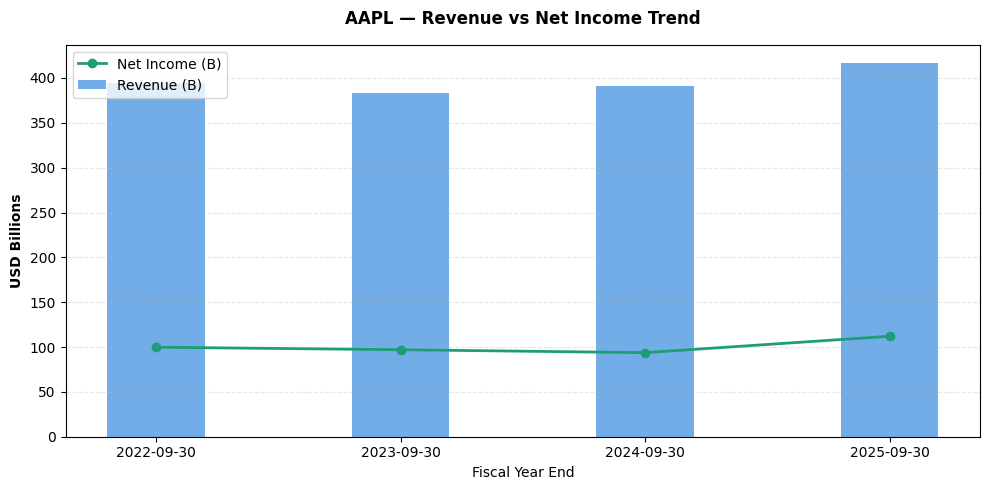

Generating Health Scorecard chart...


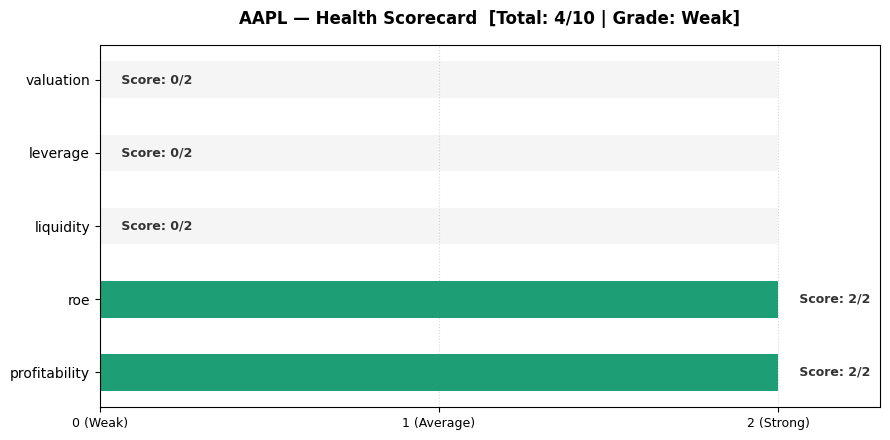

Generating Multi-Period Ratio Trends chart...


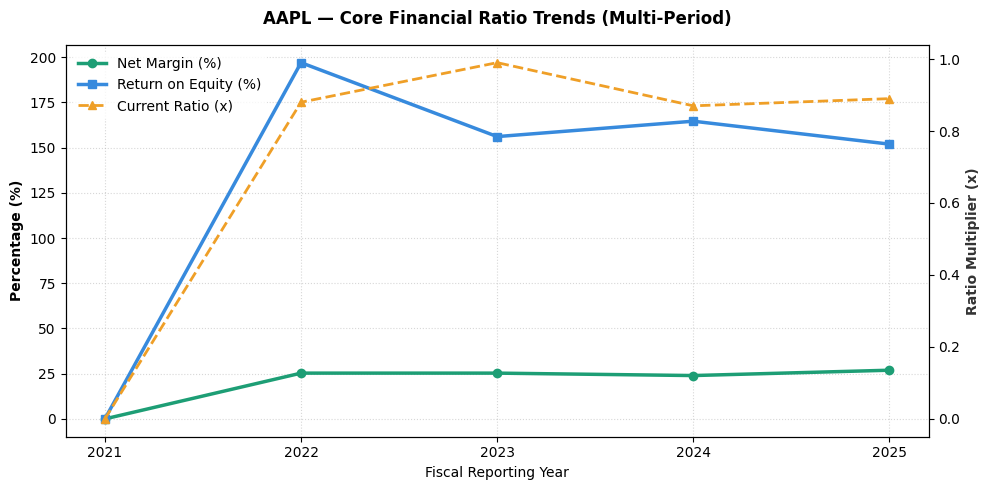


Charts saved inside the 'reports/' folder.


In [578]:
import sys
import os
import json
import pandas as pd

def analyze(ticker: str):
    print(f"\nFetching financial statements for {ticker}...")
    data = get_financials(ticker)
    
    inc = data.get("income_stmt")
    bal = data.get("balance_sheet")
    cf  = data.get("cash_flow")
    info = data.get("info", {})
    
    if inc is None or inc.empty or bal.empty or cf.empty:
        print(f"Error: Missing financial statement records for {ticker}.")
        return

    # 1. Compute historical ratios (These are dicts of multi-year Pandas Series)
    prof_hist = profitability(inc, bal)
    liq_hist = liquidity_solvency(bal)
    
    # 2. BULLETPROOF EXTRACTION: Pull index 0 from each Series to keep the dictionary keys
    latest_ratios = {}
    
    for metric_name, series in prof_hist.items():
        # Grabs the most recent year's value while keeping the metric name as the key
        latest_ratios[metric_name] = series.iloc[0] if not series.empty else 0.0
        
    for metric_name, series in liq_hist.items():
        latest_ratios[metric_name] = series.iloc[0] if not series.empty else 0.0

    # 3. Add valuation metrics (already a flat single-year dictionary)
    latest_val = valuation(info, inc, bal, cf)
    latest_ratios.update(latest_val)
    
    # Debug print statement: See exactly what keys are passing
    print("\n--- Extracted Latest Metrics Passed to Analyzer ---")
    for k, v in latest_ratios.items():
        print(f"  {k}: {v}")
    
    # 4. Calculate Scores
    print("\nEvaluating financial health score...")
    score_breakdown = overall_score(latest_ratios)
    
    print("\n=== FINAL ANALYSIS SCORES ===")
    print(score_breakdown)
    
    # 5. Plotting (Pass raw unmodified statements so the graphs remain multi-year)
    print("\n=== GENERATING VISUALIZATIONS ===")
    os.makedirs("reports", exist_ok=True)
    
    print(f"Generating Revenue vs Net Income chart...")
    plot_revenue_trend(inc, ticker)
    
    print(f"Generating Health Scorecard chart...")
    plot_scorecard(score_breakdown, ticker)
    
    # NEW: Convert historical ratio dictionaries into full multi-year DataFrames
    # and pass them directly to generate the multi-period line graph trend report.
    print(f"Generating Multi-Period Ratio Trends chart...")
    prof_df = pd.DataFrame(prof_hist)
    liq_df = pd.DataFrame(liq_hist)
    plot_ratio_trends(prof_df, liq_df, ticker)
    
    print(f"\nCharts saved inside the 'reports/' folder.")

analyze("AAPL")

### Apple Inc (AAPL) - Financial Health Analysis

#### <p style="text-align: center;">**Profitability**</p> 
* **Gross Margin**: 46.91


* **Net Margin**: 26.92 - This shows that for every `$1` in sales AAPL makes, it keeps `$0.2692`. This scores the Net Margin as "Strong."

  
* **Ebitda Margin**: 34.78

  
* **ROE**: 151.91 - ROE measures how effectively AAPL utilizes the money of its shareholders to generate profit. A `151.91%` return is exceptionally high. For context, a bank pays around `4-5%` interest. At first glance, a ROE this far above the Net Margin suggests heavy leverage, but the structural cause is more specific: AAPL has been aggressively buying back its own shares for over a decade, which shrinks the equity denominator in the ROE formula (LegalClarity Team, 2026). Less equity, same earnings, higher ROE. This is a deliberate capital return strategy, not a sign of financial distress.

  
* **ROA**: 31.18 - ROA measures how much profit AAPL generates for every `$1` of total assets it holds. A `31.18%` ROA is exceptional, meaning AAPL generates `$0.31` in profit per dollar of assets deployed. Cross-referencing this against ROE reveals the leverage effect directly: ROE stands at `151.91%` while ROA sits at `31.18%`. The gap between the two is the leverage amplification made visible, shareholders' equity is compressed, so returns on that equity look larger than the underlying asset performance actually is.

#### <p style="text-align: center;">**Liquidity**</p>
* **Current Ratio**: 0.89 - A Current Ratio of `0.89` falls below the `1.0` threshold, which would normally indicate that AAPL cannot comfortably cover its short-term obligations. However, this reading requires important context. AAPL generates over $100B in annual operating cash flow (Apple Inc., 2024a), which means it can cover short-term obligations many times over from earnings alone, without relying on balance sheet liquidity. A current ratio below `1.0` at a company this cash-generative is a sign of efficient capital management, not financial stress.


* **Quick Ratio**: 0.86 - The verdict on the Current Ratio is further supported by the Quick Ratio's value of `0.86`. This metric ignores inventory because it may take time to convert into cash. Since the difference is only `0.03` points, the short-term cushion AAPL has does not majorly rely on its inventory to pay short-term obligations. This makes sense given that AAPL outsources nearly all manufacturing (Apple Inc., 2024b). Physical stock is not a meaningful component of its current assets.

  
* **Debt-to-Equity**: 1.34 - A D/E of `1.34` says that AAPL owes `1.34` times what its shareholders own. However, this leverage did not come from operational necessity. AAPL routinely issues low-cost corporate debt specifically to fund share repurchases (AppleInsider Staff, 2021), a form of financial engineering rather than a sign that the business requires significant borrowing to function. This is distinct from the structural leverage seen in genuinely capital-intensive industries like manufacturing, mining, or utilities.

  
* **Debt-to-Assets**: 0.27 - A D/A of `0.27` directly supports this reading. Only `$0.27` of every `$1` of AAPL's total assets is financed by debt. Despite the elevated D/E, the overall balance sheet remains conservative, and the leverage concern is narrower than the D/E figure alone would suggest.

#### <p style="text-align: center;">**Valuation**</p>
* **P/E Ratio**: 38.16 - A P/E of `38.16` means investors pay `$38.16` for every `$1` of annual profit. A P/E this high reflects not just growth expectations, but also a quality premium. The market assigns AAPL a lower risk discount rate given its brand moat, ecosystem lock-in, and consistency of cash generation (Pomegra, n.d.). By this tool's scoring thresholds, a P/E above 30 scores 0, which correctly identifies that AAPL is richly valued. This is not the same as saying AAPL is a bad investment, it means the current price requires strong future performance to justify it.

  
* **P/B Ratio**: 43.42 - A P/B of `43.42` means the market values AAPL at 43 times its book value. This extreme reading is directly connected to the ROE discussion: years of share buybacks have compressed AAPL's book value to a low base, making the ratio appear large. It is a product of the same capital structure strategy, not an independent red flag.

  
* **EV/EBITDA**: 32.42 - Supporting the P/E ratio, an EV/EBITDA of `32.42` further confirms that the market is pricing in significant future growth for AAPL. With both P/E and EV/EBITDA pointing above 30 in the same direction, the valuation conclusion carries more weight than either metric alone.

  
* **FCF Yield**: 2.13 - FCF Yield measures how many cents AAPL actually generates in free cash for every dollar of market cap. At `2.13%`, the yield is low, but this signals that the stock is priced for growth rather than current cash return, not that the business itself is unhealthy. Whether this is justified depends on whether AAPL can grow its free cash flow over time. It is a valuation concern, not a health concern.

#### <p style="text-align: center;">**Analysis scores**</p>
`{'profitability': 2, 'roe': 2, 'liquidity': 0, 'leverage': 0, 'valuation': 0, '_total_score': 4, '_final_grade': 'Weak'}`


* **Profitability & ROE**: No further action needed.


* **Liquidity, Leverage, & Valuation**: Further investigation required.

#### <p style="text-align: center;">**Investigation on Liquidity, Leverage, & Valuation**</p>
* **Liquidity**: Current Ratio `(0.89)` and Quick Ratio `(0.86)` both fall below threshold, scoring 0. However, as established, this does not reflect financial stress for AAPL given its operating cash flow scale. The tool's general thresholds do not account for company-specific cash generation capacity.


* **Leverage**: D/E of `1.34` scores 0 since lower is better. However, this leverage is deliberate and tied to AAPL's buyback strategy rather than operational dependency on debt. D/A of `0.27` confirms that the overall balance sheet is not structurally overleveraged.


* **Valuation**: P/E of `38.16` exceeds the tool's weak threshold of 30, scoring 0. This correctly identifies that AAPL is expensively priced, but it does not indicate business weakness.

The tool assigns a final grade of Weak (4/10). This result requires qualification. The three zero scores on liquidity, leverage, and valuation are each explainable by structural factors specific to AAPL's capital management strategy, not by operational deterioration. The two perfect scores on profitability and ROE more accurately reflect the underlying business reality. A practitioner reading this
output would classify AAPL as a high-quality, richly-valued business, not a weak one. The tool's general thresholds are best suited for straightforward operating companies and systematically downgrade premium businesses with deliberate capital structures like AAPL's.

#### <p style="text-align: center;">**Graphs**</p>
1. **Revenue vs. Net Income Trend**
Is the company growing and keeping more of what it grows? From 2021 to 2022, both revenue and net income rose sharply, reflecting peak post-pandemic consumer demand for Apple devices and services (Apple Inc., 2022). From 2022 to 2023, both declined, driven by post-pandemic demand normalization, iPhone sales weakness in China due to Huawei competition, and foreign exchange headwinds from a strong US dollar (Apple Inc., 2023). A recovery followed in 2024, with revenue rising. However, net income continued to decline within that same period, indicating that costs were rising faster than sales, a sign of margin compression rather than revenue weakness. Both metrics then increased into 2025, suggesting the cost pressures were temporary. The dip period of 2022 to 2024 is not attributable to the pandemic, which had already passed; the causes were competitive and macroeconomic in nature.

2. **Health Scorecard**
The chart properly supports the output from the initial scorecard. Profitability and ROE appear in green, confirming the strong underlying business performance. Liquidity, leverage, and valuation appear in red, consistent with the zero scores discussed above and explainable by the same structural factors. The visual makes clear that AAPL's weakness, as defined by this tool, is concentrated entirely in its capital structure and valuation, not in its ability to generate profit.

3. **Ratio Trends**
The Net Margin saw a steady rise from 2021 to 2022 before slowly declining from 2022 to 2024, which aligns with the revenue trend discussion above, cost pressures eating into margins during that period. A recovery in 2025 suggests those pressures have since eased.

---

ROE saw a sharp increase between 2021 and 2022. This is not a sign that AAPL suddenly became more dependent on debt, but rather reflects the compounding effect of its long-running buyback program, as the equity base shrank further, the same level of earnings produced a higher ROE. It then followed the decline of Net Margin from 2022 to 2023 as earnings fell. A slight increase from 2023 to 2024, despite flat margins, indicates the buyback program continued reducing the equity base during that period, before normalizing into 2025.

The Current Ratio shows erratic movement throughout the years, indicating volatility in short-term working capital positioning. This is partly a product of active treasury management. AAPL regularly redeploys cash into buybacks and dividends on a quarterly basis rather than holding it idle, which causes the current ratio to move unpredictably. It is inconsistency driven by capital activity, not by operational instability.

---

# References

Apple Inc. (2022). *Annual report (Form 10-K) for fiscal year 2022*. Apple Inc. https://annual-statements.com/company/apple-inc/annual-report-2022-form-10k-2


Apple Inc. (2023). *Annual report pursuant to Section 13 or 15(d) of the Securities Exchange Act of 1934 (Form 10-K) for the fiscal year ended September 30, 2023*. U.S. Securities and Exchange Commission. https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm


Apple Inc. (2024a). *Annual report pursuant to Section 13 or 15(d) of the Securities Exchange Act of 1934 (Form 10-K)*. U.S. Securities and Exchange Commission. https://www.sec.gov/Archives/edgar/data/320193/000032019324000123/aapl-20240928.htm


Apple Inc. (2024b). *Consolidated financial statements*. https://www.apple.com/newsroom/pdfs/fy2024-q3/FY24_Q3_Consolidated_Financial_Statements.pdf


AppleInsider Staff. (2021, July 30). Apple issues $6.5B bond to fund buyback, acquisitions. *AppleInsider*. https://appleinsider.com/articles/21/07/30/apple-issues-65b-bond-to-fund-buyback-acquisitions


Baltova, A. (2021, January 13). Valuation ratios. *365 Financial Analyst*. https://365financialanalyst.com/knowledge-hub/financial-analysis/valuation-ratios/


Chen, J. (2023, November 10). EBITDA margin. *Investopedia*. https://www.investopedia.com/terms/e/ebitda-margin.asp


Fernando, J. (2025, June 7). Debt-to-equity (D/E) ratio formula and how to interpret it. *Investopedia*. https://www.investopedia.com/terms/d/debtequityratio.asp


*Free cash flow yield: Definition, formula, and how to calculate*. (n.d.). *Investopedia*. https://www.investopedia.com/terms/f/freecashflowyield.asp


Hayes, A. (2025, April 8). Understanding liquidity ratios: Types and their importance. *Investopedia*. https://www.investopedia.com/terms/l/liquidityratios.asp


Hayes, A. (2025, May 11). Profitability ratios: What they are, common types, and how businesses use them. *Investopedia*. https://www.investopedia.com/terms/p/profitabilityratios.asp


LegalClarity Team. (2026, April 7). How Apple's share buyback program works. *LegalClarity*. https://legalclarity.org/how-apples-share-buyback-program-works/


Pomegra. (n.d.). *Valuing Apple: A beginner walkthrough*. *Pomegra Learn Library*. https://pomegra.io/learn/library/track-b-stock-market-core/fundamental-analysis/chapter-15-worked-valuations/valuing-apple-walkthrough